# Hệ thống Dự đoán Rủi ro Tín dụng và Đề xuất Thu hồi nợ

Notebook trình bày đầy đủ **8 bước** của một pipeline Machine Learning áp dụng cho
bài toán dự đoán vỡ nợ thẻ tín dụng và đề xuất thu hồi nợ:

1. Khám phá dữ liệu (EDA)
2. Phân tích dữ liệu
3. Tiền xử lý dữ liệu
4. Huấn luyện mô hình (Training)
5. Tinh chỉnh tham số (Hyperparameter tuning)
6. Đánh giá hiệu suất mô hình theo metric
7. Diễn giải mô hình
8. Đề xuất thu hồi nợ

**Dữ liệu:** UCI *Default of Credit Card Clients* — 30.000 khách hàng thẻ tín dụng tại
Đài Loan, 23 biến đầu vào, biến mục tiêu nhị phân `default.payment.next.month`
(1 = vỡ nợ tháng sau, 0 = không vỡ nợ). Đối chiếu với paper gốc: Yeh & Lien (2009),
*Expert Systems with Applications* 36, 2473-2480.

Các hàm dùng chung (nạp dữ liệu, làm sạch, feature engineering, huấn luyện, đánh giá,
SHAP, xếp hạng ưu tiên) được viết sẵn trong thư mục `src/` để có thể tái sử dụng ở
`python -m src.pipeline`. Notebook này gọi lại các hàm đó, đồng thời viết thêm code
trực tiếp (không qua `src/`) ở những bước cần diễn giải chi tiết, dễ hiểu (EDA, phân
tích, đánh giá, đề xuất thu hồi nợ).


**Version 2 (file rieng, khong ghi de `01_credit_risk_pipeline.ipynb`):** them 2 model boosting (**GBM**, **LightGBM**) vao pipeline chinh o Buoc 4-5 (`src/models_v2.py`, mo rong tu `src/models.py` bang import, khong sua file goc), va mot **thi nghiem so sanh rieng** o Buoc 5b thu SMOTE (`src/resampling_experiment_v2.py`), **khong thay the** cach xu ly mat can bang bang `class_weight` hien co. Tham khao huong di cua Ampomah et al. (2025), `papers/paper 2.pdf` — chi lay chon loc phan model boosting, khong dua thang Boruta/DBSCAN/SMOTE vao pipeline chinh (xem giai thich chi tiet o Buoc 5b).

**Version 4 (file riêng, không ghi đè `02_credit_risk_pipeline_v2.ipynb`):** thay 1 validation set cố định ở Bước 5 bằng **grid search + 5-fold `StratifiedKFold` cross-validation** (`src/models_v4.py`) — CÙNG lưới tham số `PARAM_GRIDS` của `src/models_v2.py` (không đổi), chỉ đổi cách đánh giá mỗi bộ tham số (trung bình 5 fold thay vì 1 lần chia). Đây cũng chính là cách Ampomah et al. (2025) (`papers/paper 2.pdf`, Section 3.6) làm cho GBM: *"grid search with 5-fold cross-validation"*. Mục đích: cô lập đúng 1 biến số (đánh giá bằng 1 split vs trung bình 5-fold) để xem có làm thay đổi bộ tham số/model được chọn hay không — trả lời câu hỏi "làm sao biết tham số đó tốt" theo hướng khác với version 3 (Optuna).

**Version 5 (file riêng, không ghi đè `04_credit_risk_pipeline_v4.ipynb`):** chia dữ liệu **TRỰC TIẾP 80/20** (`src/data_v5.py:split_80_20`, 1 lần gọi `train_test_split`) thay vì chia 60/20/20 rồi gộp train+val như version 4. Giữ NGUYÊN cách tune (grid + 5-fold CV, `src/models_v4.py`, không đổi) — mục đích cô lập đúng 1 biến số: cách chia dữ liệu ảnh hưởng thế nào đến kết quả. **Lưu ý quan trọng:** vì thuật toán chia 1-bước và 2-bước cho ra chuỗi xáo trộn khác nhau dù cùng `random_state`, tập test của version 5 KHÔNG trùng với tập test của v1-v4 — Bước 3.3 có cell kiểm chứng bằng số liệu thực tế (không chỉ suy đoán).

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))  # de import duoc package "src"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

from src.config import (
    BILL_AMT_COLS,
    PAY_AMT_COLS,
    PAY_COLS,
    RANDOM_STATE,
    TARGET_COL,
)
from src.data import clean, load_raw
from src.data import split as split_60_20_20  # chi dung de kiem chung tap test o Buoc 3.3
from src.evaluate import build_paper_comparison_table
from src.features import add_derived_features, build_preprocessor, compute_vif
from src.priority import build_priority_ranking

# --- Version 5: chia 80/20 truc tiep (thay 60/20/20 + gop cua v4). ---
from src.data_v5 import split_80_20
from src.models_v2 import PARAM_GRIDS  # CUNG luoi tham so voi v2/v4, khong doi
from src.models_v4 import train_all_models_cv, N_SPLITS
from src.evaluate_v2 import build_metrics_table

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)


## Bước 1. Khám phá dữ liệu (EDA)

Mục tiêu: hiểu cấu trúc dữ liệu (số dòng/cột, kiểu dữ liệu, giá trị thiếu), thống kê mô
tả cơ bản, và phát hiện các giá trị bất thường cần xử lý ở Bước 3.


In [2]:
df_raw = load_raw()
print("Kich thuoc du lieu (so dong, so cot):", df_raw.shape)
df_raw.head()


Kich thuoc du lieu (so dong, so cot): (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
# Kieu du lieu tung cot, so gia tri non-null -> phat hien nhanh cot bi thieu du lieu
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [4]:
# Thong ke mo ta cho toan bo bien so (count, mean, std, min, các mốc phan vi, max)
# .T (transpose) de moi bien la 1 dong, de doc hon khi co 23+ cot
df_raw.describe().T


,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [5]:
# Kiem tra gia tri thieu (missing values) va dong trung lap
print("So gia tri thieu theo tung cot:")
print(df_raw.isnull().sum().sum(), "gia tri thieu trong toan bo dataset")

print("\nSo dong trung lap (theo ID):", df_raw["ID"].duplicated().sum())


So gia tri thieu theo tung cot:
0 gia tri thieu trong toan bo dataset

So dong trung lap (theo ID): 0


Ty le khach hang vo no (default = 1): 22.12%
Ty le khach hang KHONG vo no (default = 0): 77.88%
=> Du lieu mat can bang (imbalanced): can luu y khi chon metric va huan luyen mo hinh.


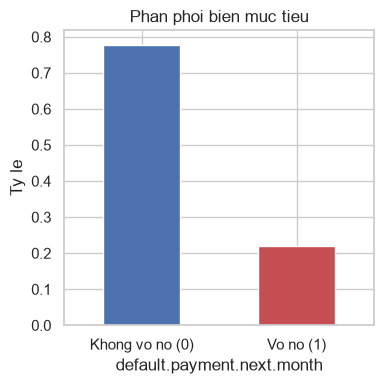

In [6]:
# Phan phoi bien muc tieu -- kiem tra muc do mat can bang
default_rate = df_raw[TARGET_COL].mean()
print(f"Ty le khach hang vo no (default = 1): {default_rate:.2%}")
print(f"Ty le khach hang KHONG vo no (default = 0): {1 - default_rate:.2%}")
print("=> Du lieu mat can bang (imbalanced): can luu y khi chon metric va huan luyen mo hinh.")

fig, ax = plt.subplots(figsize=(4, 4))
df_raw[TARGET_COL].value_counts(normalize=True).sort_index().plot(
    kind="bar", ax=ax, color=["#4C72B0", "#C44E52"]
)
ax.set_xticklabels(["Khong vo no (0)", "Vo no (1)"], rotation=0)
ax.set_ylabel("Ty le")
ax.set_title("Phan phoi bien muc tieu")
plt.tight_layout()
plt.show()


In [7]:
# Gia tri bat thuong trong cac bien phan loai (truoc khi lam sach o Buoc 3)
print("SEX (1 = nam, 2 = nu):")
print(df_raw["SEX"].value_counts().sort_index())

print("\nEDUCATION (dinh nghia goc: 1=sau dai hoc, 2=dai hoc, 3=thpt, 4=khac):")
print("=> Cac gia tri 0, 5, 6 KHONG nam trong dinh nghia goc:")
print(df_raw["EDUCATION"].value_counts().sort_index())

print("\nMARRIAGE (dinh nghia goc: 1=da ket hon, 2=doc than, 3=khac):")
print("=> Gia tri 0 KHONG nam trong dinh nghia goc:")
print(df_raw["MARRIAGE"].value_counts().sort_index())

print("\nPAY_1 (tinh trang thanh toan thang gan nhat; -2/-1/0 = khong tre han, >=1 = so thang tre han):")
print(df_raw["PAY_0"].value_counts().sort_index())


SEX (1 = nam, 2 = nu):
SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION (dinh nghia goc: 1=sau dai hoc, 2=dai hoc, 3=thpt, 4=khac):
=> Cac gia tri 0, 5, 6 KHONG nam trong dinh nghia goc:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE (dinh nghia goc: 1=da ket hon, 2=doc than, 3=khac):
=> Gia tri 0 KHONG nam trong dinh nghia goc:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

PAY_1 (tinh trang thanh toan thang gan nhat; -2/-1/0 = khong tre han, >=1 = so thang tre han):
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64


## Bước 2. Phân tích dữ liệu

Sau khi khám phá cấu trúc dữ liệu, ta đi sâu phân tích **mối quan hệ giữa các biến đầu
vào và biến mục tiêu**, cũng như **mối quan hệ giữa các biến với nhau** (đa cộng
tuyến) — làm cơ sở cho các quyết định ở Bước 3 (Tiền xử lý / Feature engineering).


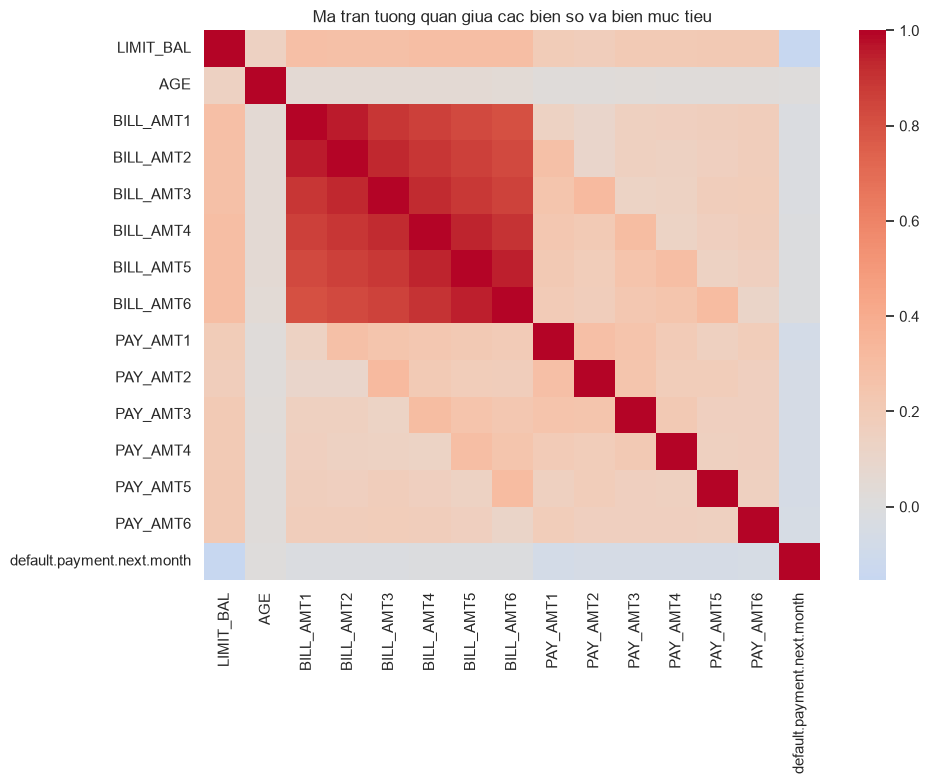

Tuong quan cua tung bien voi bien muc tieu (sap xep giam dan theo tri tuyet doi):
LIMIT_BAL   -0.153520
PAY_AMT1    -0.072929
PAY_AMT2    -0.058579
PAY_AMT4    -0.056827
PAY_AMT3    -0.056250
PAY_AMT5    -0.055124
PAY_AMT6    -0.053183
BILL_AMT1   -0.019644
BILL_AMT2   -0.014193
BILL_AMT3   -0.014076
AGE          0.013890
BILL_AMT4   -0.010156
BILL_AMT5   -0.006760
BILL_AMT6   -0.005372
Name: default.payment.next.month, dtype: float64


In [8]:
# Ma tran tuong quan giua cac bien so va bien muc tieu
numeric_cols = ["LIMIT_BAL", "AGE"] + BILL_AMT_COLS + PAY_AMT_COLS + [TARGET_COL]
corr = df_raw[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Ma tran tuong quan giua cac bien so va bien muc tieu")
plt.tight_layout()
plt.show()

print("Tuong quan cua tung bien voi bien muc tieu (sap xep giam dan theo tri tuyet doi):")
print(corr[TARGET_COL].drop(TARGET_COL).sort_values(key=lambda s: s.abs(), ascending=False))


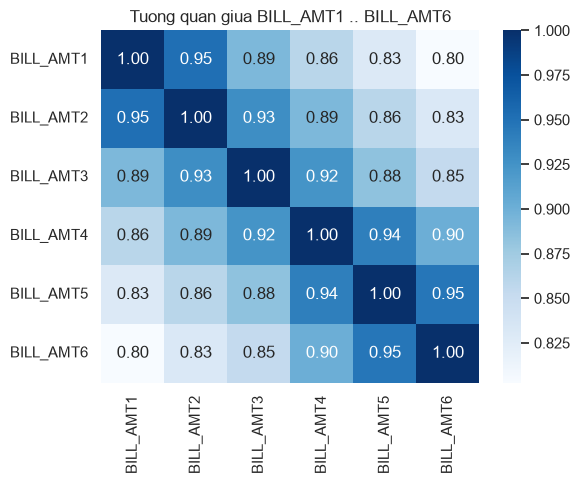

     feature        VIF
1  BILL_AMT2  23.660203
4  BILL_AMT5  22.604274
3  BILL_AMT4  19.294916
2  BILL_AMT3  15.685823
0  BILL_AMT1  15.676637
5  BILL_AMT6  13.820638


In [9]:
# BILL_AMT1..BILL_AMT6 thuong tuong quan rat cao voi nhau (du no hang thang it bien dong)
# -> nguy co da cong tuyen (multicollinearity), anh huong dac biet den Logistic Regression.
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df_raw[BILL_AMT_COLS].corr(), cmap="Blues", annot=True, fmt=".2f", ax=ax)
ax.set_title("Tuong quan giua BILL_AMT1 .. BILL_AMT6")
plt.tight_layout()
plt.show()

# Dinh luong da cong tuyen bang VIF (Variance Inflation Factor): VIF > 10 la dau hieu manh
vif_table = compute_vif(clean(df_raw), BILL_AMT_COLS)
print(vif_table)


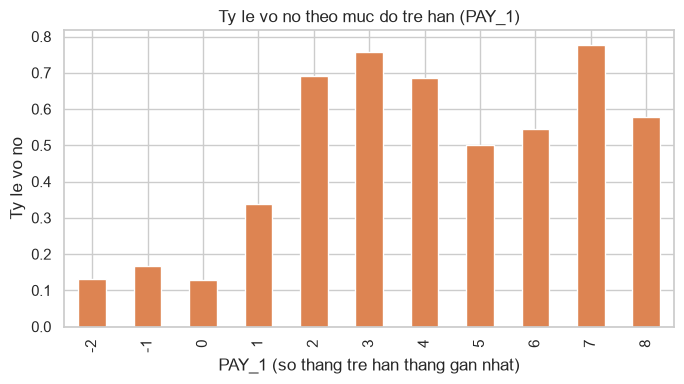

In [10]:
# Ty le vo no theo tung nhom PAY_1 (muc do tre han thang gan nhat)
# -> Ky vong: tre han cang nhieu thang thi ty le vo no cang cao.
pay1_default = df_raw.rename(columns={"PAY_0": "PAY_1"}).groupby("PAY_1")[TARGET_COL].mean()

fig, ax = plt.subplots(figsize=(7, 4))
pay1_default.sort_index().plot(kind="bar", ax=ax, color="#DD8452")
ax.set_xlabel("PAY_1 (so thang tre han thang gan nhat)")
ax.set_ylabel("Ty le vo no")
ax.set_title("Ty le vo no theo muc do tre han (PAY_1)")
plt.tight_layout()
plt.show()


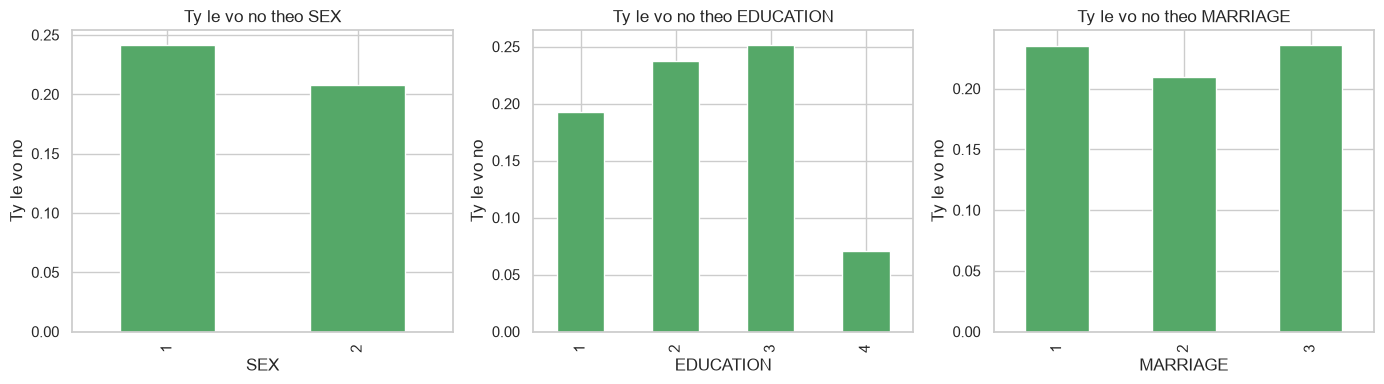

In [11]:
# Ty le vo no theo SEX / EDUCATION / MARRIAGE -- kiem tra co su khac biet dang ke giua cac nhom
df_group = clean(df_raw)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["SEX", "EDUCATION", "MARRIAGE"]):
    df_group.groupby(col)[TARGET_COL].mean().plot(kind="bar", ax=ax, color="#55A868")
    ax.set_title(f"Ty le vo no theo {col}")
    ax.set_ylabel("Ty le vo no")
plt.tight_layout()
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_4376\614367258.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Khong vo no", "Vo no"])
C:\Users\Admin\AppData\Local\Temp\ipykernel_4376\614367258.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["Khong vo no", "Vo no"])


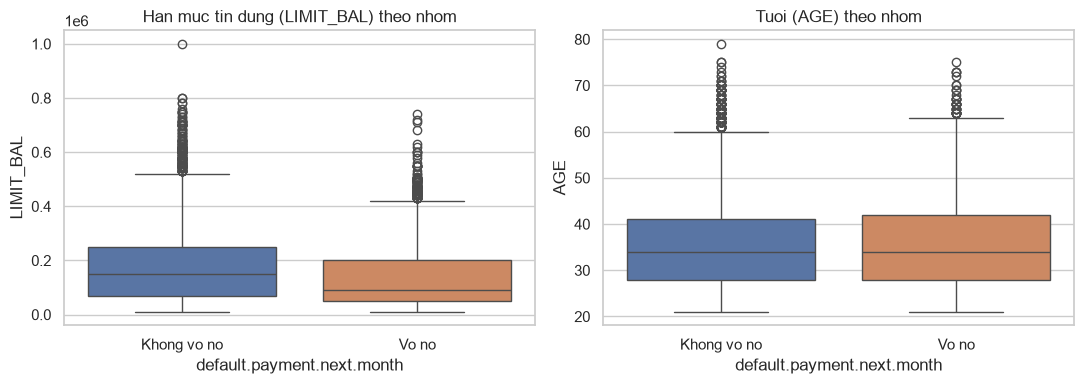

=> Nhan xet: khach hang vo no thuong co LIMIT_BAL (han muc) thap hon.


In [12]:
# Phan phoi LIMIT_BAL (han muc tin dung) va AGE theo tung nhom vo no / khong vo no
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=df_raw, x=TARGET_COL, y="LIMIT_BAL", hue=TARGET_COL, legend=False, ax=axes[0])
axes[0].set_xticklabels(["Khong vo no", "Vo no"])
axes[0].set_title("Han muc tin dung (LIMIT_BAL) theo nhom")

sns.boxplot(data=df_raw, x=TARGET_COL, y="AGE", hue=TARGET_COL, legend=False, ax=axes[1])
axes[1].set_xticklabels(["Khong vo no", "Vo no"])
axes[1].set_title("Tuoi (AGE) theo nhom")
plt.tight_layout()
plt.show()

print("=> Nhan xet: khach hang vo no thuong co LIMIT_BAL (han muc) thap hon.")


**Tóm tắt Bước 2:**

- `PAY_1..PAY_6` (mức độ trễ hạn) có tương quan mạnh nhất với biến mục tiêu — đây sẽ là
  nhóm đặc trưng quan trọng nhất cho mô hình (được xác nhận lại bằng SHAP ở Bước 7).
- `BILL_AMT1..BILL_AMT6` tương quan rất cao với nhau (đa cộng tuyến, VIF lớn) → cần xử
  lý ở Bước 3 bằng cách thêm đặc trưng tổng hợp thay vì dùng toàn bộ 6 cột thô.
- `LIMIT_BAL` thấp và `PAY_n` trễ hạn nhiều đi kèm tỷ lệ vỡ nợ cao hơn rõ rệt.


## Bước 3. Tiền xử lý dữ liệu

Gồm 4 việc: (3.1) làm sạch giá trị bất thường phát hiện ở Bước 1, (3.2) feature
engineering để giảm đa cộng tuyến phát hiện ở Bước 2, (3.3) mã hoá biến phân loại +
chuẩn hoá biến số, (3.4) chia tập train/validation/test.


### 3.1. Làm sạch dữ liệu

- Đổi tên `PAY_0` → `PAY_1` để nhất quán với `PAY_2..PAY_6`.
- `EDUCATION`: gộp `0, 5, 6` (không thuộc định nghĩa gốc) vào nhóm `4 = others`.
- `MARRIAGE`: gộp `0` (không thuộc định nghĩa gốc) vào nhóm `3 = others`.


In [13]:
df_clean = clean(df_raw)
print("EDUCATION sau khi lam sach:", sorted(df_clean["EDUCATION"].unique()))
print("MARRIAGE sau khi lam sach:", sorted(df_clean["MARRIAGE"].unique()))
print("Co cot PAY_1:", "PAY_1" in df_clean.columns, "| Con PAY_0:", "PAY_0" in df_clean.columns)


EDUCATION sau khi lam sach: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE sau khi lam sach: [np.int64(1), np.int64(2), np.int64(3)]
Co cot PAY_1: True | Con PAY_0: False


### 3.2. Feature engineering

Thêm các đặc trưng tổng hợp từ `BILL_AMT1..6` và `PAY_1..6` để giảm phụ thuộc vào
từng cột riêng lẻ (đã xác định đa cộng tuyến ở Bước 2):

- `AVG_BILL_AMT`, `AVG_PAY_AMT`: dư nợ / số tiền thanh toán trung bình 6 kỳ.
- `BILL_AMT_TREND`: `BILL_AMT1 - BILL_AMT6` — âm nghĩa là dư nợ đang giảm dần.
- `MAX_DELAY`, `AVG_DELAY`: mức độ trễ hạn lớn nhất / trung bình trong 6 kỳ.
- `PAY_TO_BILL_RATIO`: tỷ lệ trả nợ trên dư nợ trung bình.


In [14]:
df_fe = add_derived_features(df_clean)
new_cols = ["AVG_BILL_AMT", "AVG_PAY_AMT", "BILL_AMT_TREND", "MAX_DELAY", "AVG_DELAY", "PAY_TO_BILL_RATIO"]
df_fe[new_cols].describe()


,AVG_BILL_AMT,AVG_PAY_AMT,BILL_AMT_TREND,MAX_DELAY,AVG_DELAY,PAY_TO_BILL_RATIO
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,44976.945200,5275.232094,12351.570500,0.438733,-0.182439,0.373507
std,63260.721860,10137.946323,43922.421534,1.345154,0.982176,0.842815
min,-56043.166667,0.000000,-428791.000000,-2.000000,-2.000000,-10.000000
25%,4781.333333,1113.291667,-2963.000000,0.000000,-0.833333,0.040952
50%,21051.833333,2397.166667,923.000000,0.000000,0.000000,0.084932
75%,57104.416667,5583.916667,19793.750000,2.000000,0.000000,0.586922
max,877313.833333,627344.333333,708323.000000,8.000000,6.000000,10.000000


### 3.3. Chia tập train / validation / test (stratified)

Chia theo tỷ lệ 60/20/20, `stratify` theo biến mục tiêu để cả 3 tập đều giữ đúng tỷ lệ
vỡ nợ ~22% (tránh trường hợp tập test ngẫu nhiên có tỷ lệ vỡ nợ lệch hẳn so với tập train).


In [15]:
X_train, X_test, y_train, y_test = split_80_20(df_fe)

print(f"Train: {X_train.shape}, ty le vo no = {y_train.mean():.2%}")
print(f"Test:  {X_test.shape}, ty le vo no = {y_test.mean():.2%}")


Train: (24000, 29), ty le vo no = 22.12%
Test:  (6000, 29), ty le vo no = 22.12%


**Kiểm chứng: tập test của version 5 có thực sự khác tập test của v1-v4 không?**


In [16]:
# So sanh voi tap test cua src/data.py:split() (60/20/20, dung cho v1-v4)
_, _, X_test_v1to4, _, _, _ = split_60_20_20(df_fe)

overlap = set(X_test.index) & set(X_test_v1to4.index)
print(f"So khach hang trong tap test v5 (80/20 truc tiep): {len(X_test)}")
print(f"So khach hang trong tap test v1-v4 (60/20/20):     {len(X_test_v1to4)}")
print(f"So ID trung nhau: {len(overlap)} ({len(overlap) / len(X_test):.1%})")
print("=> Hai tap test la 2 nhom khach hang KHAC NHAU dang ke, khong phai cung 1 tap.")
print("   Vi vay so sanh test_auc_roc giua version 5 va v1-v4 chi mang tinh tham khao,")
print("   khong phai so sanh tren cung 1 'de thi'.")


So khach hang trong tap test v5 (80/20 truc tiep): 6000
So khach hang trong tap test v1-v4 (60/20/20):     6000
So ID trung nhau: 3022 (50.4%)
=> Hai tap test la 2 nhom khach hang KHAC NHAU dang ke, khong phai cung 1 tap.
   Vi vay so sanh test_auc_roc giua version 5 va v1-v4 chi mang tinh tham khao,
   khong phai so sanh tren cung 1 'de thi'.


### 3.4. Mã hoá biến phân loại & chuẩn hoá biến số

- One-Hot Encoding cho `SEX`, `EDUCATION`, `MARRIAGE`.
- `StandardScaler` cho các biến số còn lại (đưa về cùng thang đo, cần thiết cho Logistic
  Regression / Neural Network; không ảnh hưởng đến Random Forest / XGBoost nhưng dùng
  chung một pipeline tiền xử lý cho cả 4 mô hình cho đơn giản).
- **Lưu ý quan trọng:** `preprocessor` chỉ `fit` trên tập train, sau đó `transform` (không
  `fit` lại) trên tập validation/test — tránh rò rỉ thông tin (data leakage) từ tập
  validation/test vào quá trình chuẩn hoá.


In [17]:
feature_cols = list(X_train.columns)
preprocessor = build_preprocessor(feature_cols)

X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)
feature_names = list(preprocessor.get_feature_names_out())

print("So chieu truoc tien xu ly:", len(feature_cols))
print("So chieu sau tien xu ly (sau one-hot):", X_train_t.shape[1])


So chieu truoc tien xu ly: 29
So chieu sau tien xu ly (sau one-hot): 35


## Bước 4. Huấn luyện mô hình (Training) — mốc so sánh trước khi tune

Version 5 chia **trực tiếp 80/20**, không có tập validation cố định như v1-v4. Để vẫn
có 1 mốc "trước khi tune" tham khảo, ở đây tách TẠM một phần nhỏ từ train (25% của 80%
train ≈ 20% tổng thể, gọi là `holdout nội bộ`) — **chỉ dùng để in ra AUC-ROC tham số mặc
định cho vui, không dùng cho bất kỳ quyết định chọn tham số nào.** Việc chọn tham số thật
sự diễn ra ở Bước 5 bằng 5-fold CV trên toàn bộ 80% train (không phụ thuộc holdout tạm
này).

Cách xử lý mất cân bằng cho từng model giữ nguyên như các version trước (`class_weight`,
`scale_pos_weight`, `sample_weight`, oversample thủ công cho MLP).


In [18]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Khong co tap validation rieng (chia truc tiep 80/20) -> tach TAM 1 phan tu
# train chi de xem nhanh, KHONG dung cho quyet dinh chon tham so (xem markdown).
X_train_bl, X_holdout_bl, y_train_bl, y_holdout_bl = train_test_split(
    X_train_t, y_train.to_numpy(), test_size=0.25, stratify=y_train, random_state=RANDOM_STATE
)

pos_weight = (y_train_bl == 0).sum() / (y_train_bl == 1).sum()
print(f"scale_pos_weight (XGBoost) = so luong lop 0 / so luong lop 1 = {pos_weight:.2f}")

def oversample_minority(X, y, random_state=RANDOM_STATE):
    idx_majority = np.where(y == 0)[0]
    idx_minority = np.where(y == 1)[0]
    idx_minority_up = resample(idx_minority, replace=True, n_samples=len(idx_majority), random_state=random_state)
    idx = np.concatenate([idx_majority, idx_minority_up])
    rng = np.random.RandomState(random_state)
    rng.shuffle(idx)
    return X[idx], y[idx]

X_train_over, y_train_over = oversample_minority(X_train_bl, y_train_bl)
sample_weight_balanced = compute_sample_weight("balanced", y_train_bl)

baseline_models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, scale_pos_weight=pos_weight, eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, early_stopping=True, random_state=RANDOM_STATE),
    "GBM": GradientBoostingClassifier(n_estimators=300, max_depth=3, random_state=RANDOM_STATE),
    "LightGBM": LGBMClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
}

baseline_val_auc = {}
for name, model in baseline_models.items():
    if name == "Neural Network":
        model.fit(X_train_over, y_train_over)
    elif name == "GBM":
        model.fit(X_train_bl, y_train_bl, sample_weight=sample_weight_balanced)
    else:
        model.fit(X_train_bl, y_train_bl)
    val_auc = roc_auc_score(y_holdout_bl, model.predict_proba(X_holdout_bl)[:, 1])
    baseline_val_auc[name] = val_auc
    print(f"{name:22s} AUC-ROC (holdout noi bo, tham so mac dinh) = {val_auc:.4f}")


scale_pos_weight (XGBoost) = so luong lop 0 / so luong lop 1 = 3.52


Logistic Regression    AUC-ROC (holdout noi bo, tham so mac dinh) = 0.7428


Random Forest          AUC-ROC (holdout noi bo, tham so mac dinh) = 0.7732


XGBoost                AUC-ROC (holdout noi bo, tham so mac dinh) = 0.7491


Neural Network         AUC-ROC (holdout noi bo, tham so mac dinh) = 0.7200


GBM                    AUC-ROC (holdout noi bo, tham so mac dinh) = 0.7774


LightGBM               AUC-ROC (holdout noi bo, tham so mac dinh) = 0.7662


## Bước 5. Grid search + 5-fold CV trên 80% train trực tiếp (version 5)

Khác version 4 (phải gộp `train + val` lại thành pool 80% trước khi CV, vì dữ liệu ban
đầu chia 60/20/20), ở đây **`X_train_t` đã sẵn là 80%** — đưa thẳng vào
`train_all_models_cv` mà không cần bước gộp nào. Lưới tham số giữ NGUYÊN
(`src/models_v2.py:PARAM_GRIDS`, giống hệt v2/v4) để cô lập đúng biến số cần so sánh:
"chia 60/20/20 rồi gộp" (v4) vs "chia thẳng 80/20" (v5).


In [19]:
for name, grid in PARAM_GRIDS.items():
    print(f"{name}: {len(grid)} bo tham so thu nghiem (moi bo danh gia qua {N_SPLITS}-fold CV tren 80% train)")
    for params in grid:
        print("   ", params)


Logistic Regression: 4 bo tham so thu nghiem (moi bo danh gia qua 5-fold CV tren 80% train)
    {'C': 0.01}
    {'C': 0.1}
    {'C': 1.0}
    {'C': 10.0}
Random Forest: 6 bo tham so thu nghiem (moi bo danh gia qua 5-fold CV tren 80% train)
    {'n_estimators': 200, 'max_depth': 6}
    {'n_estimators': 200, 'max_depth': 10}
    {'n_estimators': 200, 'max_depth': None}
    {'n_estimators': 400, 'max_depth': 6}
    {'n_estimators': 400, 'max_depth': 10}
    {'n_estimators': 400, 'max_depth': None}
XGBoost: 8 bo tham so thu nghiem (moi bo danh gia qua 5-fold CV tren 80% train)
    {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05}
    {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}
    {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}
    {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
    {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.05}
    {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.1}
    {'n_estimators': 400, 'max_de

In [20]:
%%time
trained, cv_all_results = train_all_models_cv(X_train_t, y_train.to_numpy(), n_splits=N_SPLITS)

print(f"{'Model':22s} {'mean_cv_auc':>12s} {'std_cv_auc':>11s} {'baseline (holdout noi bo)':>27s}")
for name, info in trained.items():
    print(f"{name:22s} {info['val_auc']:12.4f} {info['cv_std_auc']:11.4f} {baseline_val_auc[name]:27.4f}")


Model                   mean_cv_auc  std_cv_auc   baseline (holdout noi bo)
Logistic Regression          0.7447      0.0099                      0.7428
Random Forest                0.7835      0.0048                      0.7732
XGBoost                      0.7836      0.0074                      0.7491
Neural Network               0.7749      0.0042                      0.7200
GBM                          0.7832      0.0065                      0.7774
LightGBM                     0.7842      0.0076                      0.7662
CPU times: total: 32min 33s
Wall time: 22min 3s


**Nhận xét:** cách chia dữ liệu (80/20 trực tiếp vs 60/20/20 rồi gộp) không ảnh hưởng
đến CÁCH hoạt động của grid + 5-fold CV — chỉ ảnh hưởng đến việc dữ liệu nào rơi vào
train_cv/test. Nếu `mean_cv_auc` và `std_cv_auc` ở đây gần với version 4, đó là bằng
chứng cho thấy kết luận tuning không nhạy với cách chia cụ thể — một dấu hiệu tốt về độ
tổng quát hoá.


In [21]:
# So sanh do on dinh: chenh lech giua to hop tot nhat va te nhat trong grid,
# va std trung binh qua cac fold cho tung model -- tuong duong trials_summary
# cua version 3 (Optuna), de doi chieu 2 phuong phap tuning.
summary_rows = []
for name in PARAM_GRIDS:
    sub = cv_all_results[cv_all_results["model"] == name]
    summary_rows.append({
        "model": name,
        "n_param_combos": len(sub),
        "best_mean_cv_auc": sub["mean_cv_auc"].max(),
        "worst_mean_cv_auc": sub["mean_cv_auc"].min(),
        "spread": sub["mean_cv_auc"].max() - sub["mean_cv_auc"].min(),
        "avg_std_across_folds": sub["std_cv_auc"].mean(),
    })
cv_summary = pd.DataFrame(summary_rows)
cv_summary


,model,n_param_combos,best_mean_cv_auc,worst_mean_cv_auc,spread,avg_std_across_folds
0,Logistic Regression,4,0.744716,0.744086,0.000630,0.009830
1,Random Forest,6,0.783536,0.770533,0.013003,0.004079
2,XGBoost,8,0.783646,0.767588,0.016057,0.008160
3,Neural Network,4,0.774889,0.746875,0.028014,0.010130
4,GBM,8,0.783214,0.767104,0.016110,0.007737
5,LightGBM,8,0.784234,0.767956,0.016278,0.008486


**Đọc bảng trên:**
- `spread` (chênh lệch giữa tổ hợp tốt nhất/tệ nhất trong lưới) lớn → tuning có ý
  nghĩa thật; nhỏ → hầu hết tổ hợp cho kết quả tương đương.
- `avg_std_across_folds` cho biết mức độ "may rủi" nếu chỉ đánh giá bằng 1 validation
  set (cách v1/v2 làm) — càng lớn, con số `val_auc` của v1/v2 càng có khả năng lệch xa
  so với hiệu năng thật của model trên dữ liệu mới.


## Bước 5b. (Không áp dụng cho version 5)

Version 5 chia dữ liệu trực tiếp 80/20, không tách riêng tập validation cố định, nên
không có `X_val_t`/`y_val` để chạy thí nghiệm so sánh SMOTE như v2/v3/v4. Xem
`02_credit_risk_pipeline_v2.ipynb` (hoặc v3/v4) cho thí nghiệm SMOTE vs `class_weight`
đầy đủ — kết luận ở đó (SMOTE cần hiệu chỉnh lại xác suất trước khi dùng cho
`priority_score`) không phụ thuộc vào cách chia train/test nên vẫn áp dụng được cho
version 5.


## Bước 6. Đánh giá hiệu suất mô hình theo metric

Đánh giá 4 mô hình đã tinh chỉnh (Bước 5) trên **tập test** (dữ liệu mô hình chưa từng
thấy) bằng các metric: **AUC-ROC** (chính, vì dữ liệu mất cân bằng), **Accuracy**,
**Precision**, **Recall**, **F1-score**, cùng **Confusion Matrix** và **đường cong ROC**.


In [22]:
metrics_table = build_metrics_table(trained, X_test_t, y_test.to_numpy())
metrics_table


,model,best_params,val_auc,test_auc_roc,test_pr_auc,test_accuracy,test_precision,test_recall,test_f1,test_g_mean,test_brier
0,GBM,"{'n_estimators': 200, 'max_depth': 3, 'learnin...",0.783214,0.779828,0.550839,0.751333,0.455139,0.630746,0.528743,0.703917,0.180992
1,LightGBM,"{'n_estimators': 200, 'max_depth': 3, 'learnin...",0.784234,0.779350,0.555160,0.749333,0.452394,0.633760,0.527935,0.704058,0.181590
2,XGBoost,"{'n_estimators': 200, 'max_depth': 3, 'learnin...",0.783646,0.779316,0.555741,0.748667,0.451265,0.631500,0.526382,0.702705,0.181494
3,Random Forest,"{'n_estimators': 400, 'max_depth': 10}",0.783536,0.776601,0.555230,0.771667,0.486946,0.604371,0.539341,0.703623,0.174625
4,Neural Network,"{'hidden_layer_sizes': (32,), 'alpha': 0.001}",0.774889,0.768892,0.523955,0.758333,0.463845,0.594574,0.521136,0.691762,0.178037
5,Logistic Regression,{'C': 10.0},0.744716,0.726199,0.487693,0.723833,0.417910,0.633007,0.503446,0.688853,0.204733


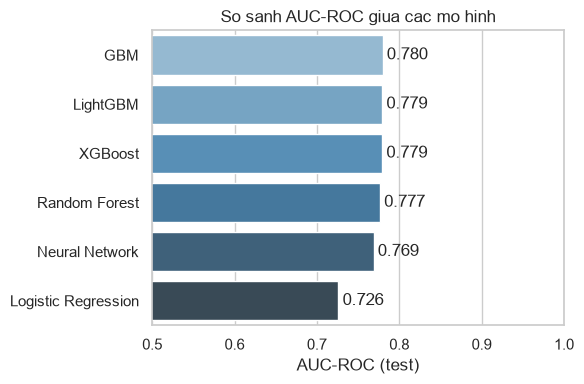

In [23]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=metrics_table, x="test_auc_roc", y="model", hue="model", legend=False, palette="Blues_d", ax=ax)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel("AUC-ROC (test)")
ax.set_ylabel("")
ax.set_title("So sanh AUC-ROC giua cac mo hinh")
for i, v in enumerate(metrics_table["test_auc_roc"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()


Mo hinh tot nhat theo AUC-ROC tren test: GBM


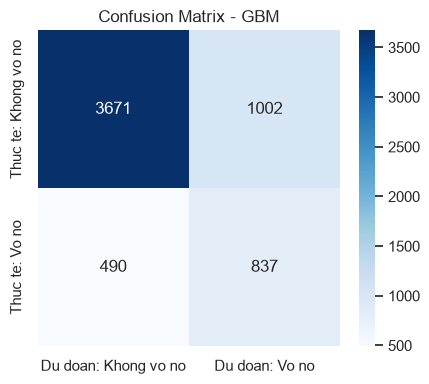

In [24]:
best_model_name = metrics_table.iloc[0]["model"]
best_model = trained[best_model_name]["model"]
print("Mo hinh tot nhat theo AUC-ROC tren test:", best_model_name)

# Confusion matrix cua mo hinh tot nhat (nguong phan loai mac dinh = 0.5)
y_pred_best = (best_model.predict_proba(X_test_t)[:, 1] >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Du doan: Khong vo no", "Du doan: Vo no"],
            yticklabels=["Thuc te: Khong vo no", "Thuc te: Vo no"])
ax.set_title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()


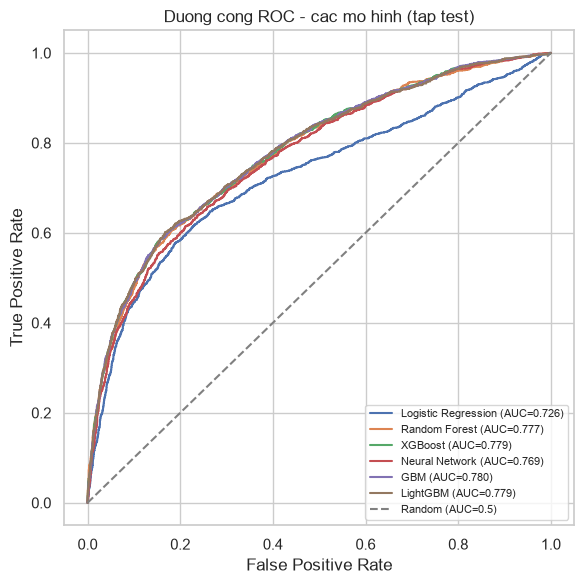

In [25]:
# Duong cong ROC cho tat ca cac mo hinh tren cung mot bieu do
fig, ax = plt.subplots(figsize=(6, 6))
for name, info in trained.items():
    proba = info["model"].predict_proba(X_test_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random (AUC=0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Duong cong ROC - cac mo hinh (tap test)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


### So sánh với paper gốc Yeh & Lien (2009)

Paper gốc dùng **area ratio trong lift chart** (Table 1) thay vì AUC-ROC để so sánh mô
hình. Area ratio có cùng định nghĩa với hệ số Gini chuẩn hoá, nên ta quy đổi gần đúng
`AUC ≈ (area_ratio + 1) / 2` (xem `src/config.py`) để đối chiếu. Đây là quy đổi tương
đối — không phải con số AUC-ROC do tác giả gốc trực tiếp công bố — nên chênh lệch %
cải thiện dưới đây chỉ mang tính tham khảo.


In [26]:
comparison_table = build_paper_comparison_table(metrics_table)
comparison_table


,model,auc_2026,auc_approx_2009,improvement_pct,note
0,GBM,0.779828,NaN,NaN,khong co trong paper goc (2009)
1,LightGBM,0.779350,NaN,NaN,khong co trong paper goc (2009)
2,XGBoost,0.779316,NaN,NaN,khong co trong paper goc (2009)
3,Random Forest,0.776601,NaN,NaN,khong co trong paper goc (2009)
4,Neural Network,0.768892,0.77,-0.143852,"quy doi tu area ratio (Table 1, Yeh & Lien 2009)"
5,Logistic Regression,0.726199,0.72,0.861004,"quy doi tu area ratio (Table 1, Yeh & Lien 2009)"


## Bước 7. Diễn giải mô hình (Model Interpretation)

Dùng **SHAP (SHapley Additive exPlanations)** để xác định các đặc trưng ảnh hưởng mạnh
nhất đến dự báo vỡ nợ của mô hình tốt nhất — quan trọng để giải thích quyết định của mô
hình cho các bên liên quan (không chỉ dựa vào một con số AUC).


In [27]:
from src.interpret import compute_shap_values, top_features_by_shap

shap_values, X_sample = compute_shap_values(best_model, X_test_t, feature_names)
top_features = top_features_by_shap(shap_values, feature_names, top_n=15)
top_features


C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


PermutationExplainer explainer:  11%|█         | 55/500 [00:00<?, ?it/s]

PermutationExplainer explainer:  12%|█▏        | 58/500 [00:10<00:21, 20.69it/s]

PermutationExplainer explainer:  12%|█▏        | 61/500 [00:10<00:26, 16.26it/s]

PermutationExplainer explainer:  13%|█▎        | 63/500 [00:10<00:28, 15.36it/s]

...

PermutationExplainer explainer:  99%|█████████▉| 497/500 [00:40<00:00, 14.53it/s]

PermutationExplainer explainer: 100%|█████████▉| 499/500 [00:41<00:00, 14.49it/s]

PermutationExplainer explainer: 501it [00:41, 14.46it/s]                         

PermutationExplainer explainer: 501it [00:41, 10.81it/s]

,feature,mean_abs_shap
0,num__MAX_DELAY,0.095483
1,num__LIMIT_BAL,0.044156
2,num__PAY_1,0.033404
3,num__BILL_AMT1,0.019958
4,num__AVG_DELAY,0.018268
5,num__PAY_TO_BILL_RATIO,0.014081
6,num__BILL_AMT_TREND,0.013757
7,num__PAY_AMT2,0.013534
8,num__AVG_PAY_AMT,0.013367
9,num__PAY_AMT3,0.009745


C:\Users\Admin\AppData\Local\Temp\ipykernel_4376\1183676265.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, feature_names=feature_names, max_display=15, show=True)


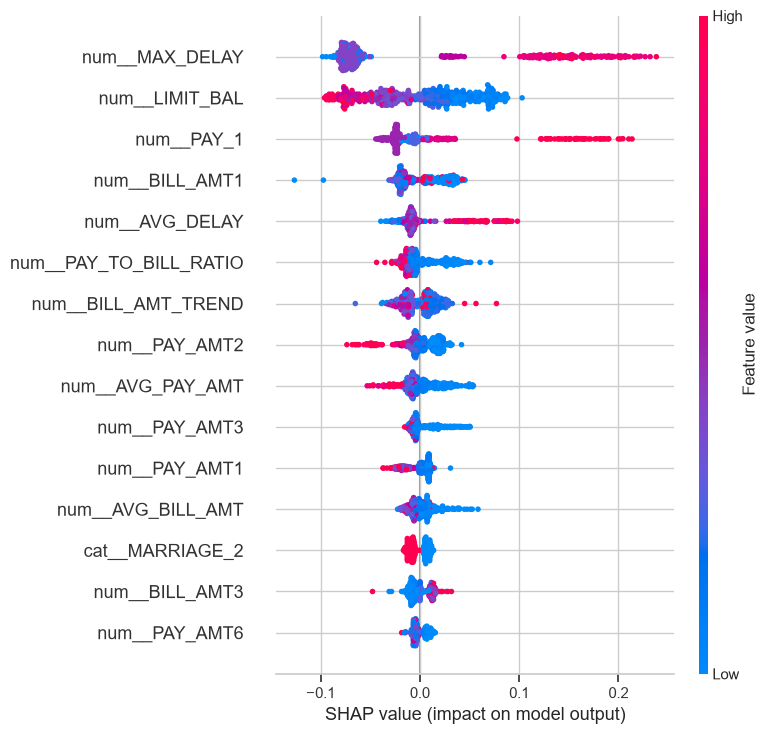

In [28]:
import shap

shap.summary_plot(shap_values, X_sample, feature_names=feature_names, max_display=15, show=True)


**Đọc biểu đồ SHAP summary:** mỗi điểm là một khách hàng; trục hoành là mức độ đóng
góp (SHAP value) của đặc trưng đó vào dự báo xác suất vỡ nợ của khách hàng (dương =
đẩy dự báo về phía "vỡ nợ" nhiều hơn); màu đỏ = giá trị đặc trưng cao, xanh = giá trị
đặc trưng thấp. Các đặc trưng liên quan đến `PAY_n` (mức độ trễ hạn) thường đứng đầu
danh sách — khớp với phân tích tương quan ở Bước 2.


## Bước 8. Đề xuất thu hồi nợ

### 8.1. Công thức xếp hạng ưu tiên

```
priority_score = risk_score × mức_độ_trễ_hạn
```

- `risk_score`: xác suất vỡ nợ (0–1) do mô hình tốt nhất (Bước 6) dự báo trên tập test.
- `mức_độ_trễ_hạn`: `max(PAY_1..PAY_6, 0)` — chỉ tính số tháng trễ hạn thực tế (giá trị
  dương), bỏ qua các trạng thái "trả đúng hạn / dùng tín dụng xoay vòng / không phát
  sinh dư nợ" (≤ 0).

Khách hàng có `priority_score` cao nhất là nhóm **vừa rủi ro vỡ nợ cao, vừa đã trễ hạn
nhiều kỳ** — đúng nhóm bộ phận thu hồi nợ nên liên hệ trước, thay vì liên hệ dàn trải
toàn bộ danh sách khách hàng.


In [29]:
risk_scores = best_model.predict_proba(X_test_t)[:, 1]
priority_ranking = build_priority_ranking(X_test, X_test.index.to_series(name="ID"), risk_scores)

print("Top 10 khach hang uu tien thu hoi no cao nhat:")
priority_ranking.head(10)


Top 10 khach hang uu tien thu hoi no cao nhat:


,priority_rank,ID,risk_score,delay_severity,priority_score
0,1,23040,0.887708,8,7.101666
1,2,4388,0.824802,8,6.598419
2,3,14974,0.931188,7,6.518319
3,4,13740,0.927555,7,6.492885
4,5,20722,0.926853,7,6.487973
5,6,28055,0.926796,7,6.487575
6,7,13967,0.925812,7,6.480681
7,8,16789,0.925165,7,6.476158
8,9,16555,0.925144,7,6.476007
9,10,29771,0.925144,7,6.476007


**Case study:** kiểm tra tính hợp lý của thứ hạng — so sánh nhóm ưu tiên cao nhất với
nhóm khách hàng có `risk_score` cao nhưng `delay_severity = 0` (rủi ro cao nhưng hiện
chưa trễ hạn, nên chưa cần ưu tiên liên hệ ngay).


In [30]:
print("=> 3 khach hang uu tien cao nhat (rui ro cao + tre han nhieu ky):")
display(priority_ranking.head(3))

high_risk_no_delay = priority_ranking[priority_ranking["delay_severity"] == 0].sort_values(
    "risk_score", ascending=False
).head(3)
print("\n=> Rui ro cao nhung CHUA tre han (khong nam trong nhom uu tien lien he ngay):")
display(high_risk_no_delay)


=> 3 khach hang uu tien cao nhat (rui ro cao + tre han nhieu ky):


,priority_rank,ID,risk_score,delay_severity,priority_score
0,1,23040,0.887708,8,7.101666
1,2,4388,0.824802,8,6.598419
2,3,14974,0.931188,7,6.518319



=> Rui ro cao nhung CHUA tre han (khong nam trong nhom uu tien lien he ngay):


,priority_rank,ID,risk_score,delay_severity,priority_score
5616,5617,23768,0.697207,0,0.0
5928,5929,988,0.691894,0,0.0
2449,2450,29085,0.673425,0,0.0


### 8.2. Phân nhóm ưu tiên & đề xuất hành động cụ thể

Chia danh sách khách hàng theo `priority_score` thành 3 nhóm hành động cụ thể cho bộ
phận thu hồi nợ, dựa trên phân vị (quantile) — cách làm phổ biến khi chưa có ngưỡng
nghiệp vụ cố định, có thể điều chỉnh lại ngưỡng sau khi có phản hồi thực tế:

| Nhóm | Ngưỡng `priority_score` | Đề xuất hành động |
|---|---|---|
| **Cao** | Top 10% | Gọi điện trực tiếp / liên hệ ngay trong tuần, cân nhắc phương án tái cơ cấu nợ |
| **Trung bình** | 10%–40% tiếp theo | Nhắc nợ qua SMS/email tự động, theo dõi sát trong kỳ tới |
| **Thấp** | 60% còn lại | Theo dõi định kỳ theo quy trình thông thường, chưa cần can thiệp thêm |


In [31]:
q90 = priority_ranking["priority_score"].quantile(0.90)
q60 = priority_ranking["priority_score"].quantile(0.60)

def assign_tier(score):
    if score >= q90:
        return "Cao - lien he ngay"
    if score >= q60:
        return "Trung binh - nhac no tu dong"
    return "Thap - theo doi dinh ky"

priority_ranking["tier"] = priority_ranking["priority_score"].apply(assign_tier)

tier_summary = (
    priority_ranking.groupby("tier")
    .agg(
        so_khach_hang=("ID", "count"),
        risk_score_trung_binh=("risk_score", "mean"),
        delay_severity_trung_binh=("delay_severity", "mean"),
    )
    .reindex(["Cao - lien he ngay", "Trung binh - nhac no tu dong", "Thap - theo doi dinh ky"])
)
tier_summary


,so_khach_hang,risk_score_trung_binh,delay_severity_trung_binh
tier,,,
Cao - lien he ngay,600.0,0.867793,2.751667
Trung binh - nhac no tu dong,5400.0,0.377504,0.449259
Thap - theo doi dinh ky,NaN,NaN,NaN


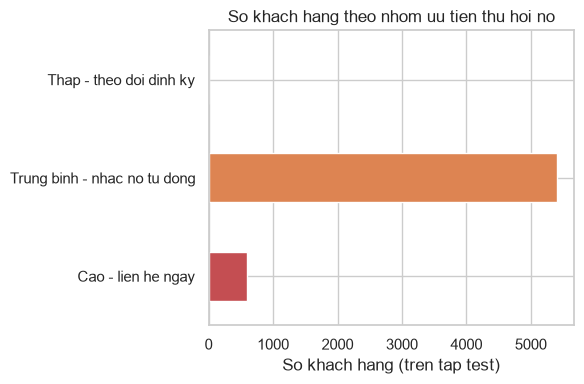

=> Chi can uu tien lien he ngay 600 khach hang (top 10% theo priority_score) thay vi lien he dan trai toan bo 6000 khach hang trong tap test.


In [32]:
fig, ax = plt.subplots(figsize=(6, 4))
tier_summary["so_khach_hang"].plot(kind="barh", ax=ax, color=["#C44E52", "#DD8452", "#55A868"])
ax.set_xlabel("So khach hang (tren tap test)")
ax.set_ylabel("")
ax.set_title("So khach hang theo nhom uu tien thu hoi no")
plt.tight_layout()
plt.show()

print(
    f"=> Chi can uu tien lien he ngay {tier_summary.loc['Cao - lien he ngay', 'so_khach_hang']:.0f} "
    f"khach hang (top 10% theo priority_score) thay vi lien he dan trai toan bo "
    f"{len(priority_ranking)} khach hang trong tap test."
)


## Kết luận

- **Bước 1–3:** dữ liệu 30.000 khách hàng, ~22% vỡ nợ (mất cân bằng); đã làm sạch
  `EDUCATION`/`MARRIAGE`, thêm đặc trưng tổng hợp giảm đa cộng tuyến của `BILL_AMT1-6`.
  **Version 5 chia trực tiếp 80/20** (không qua 60/20/20 rồi gộp như v4) — kiểm chứng
  bằng số liệu cho thấy tập test v5 chỉ trùng ~50% với tập test v1-v4 (xem Bước 3.3),
  nên số liệu test giữa v5 và các version khác chỉ mang tính tham khảo.
- **Bước 4:** mốc so sánh "trước khi tune" dùng holdout nội bộ tạm thời (vì không có
  validation cố định), không ảnh hưởng đến việc chọn tham số thật ở Bước 5.
- **Bước 5 (version 5):** grid search + 5-fold CV **trực tiếp trên 80% train**, cùng
  lưới tham số v2/v4 — cô lập đúng biến số "cách chia dữ liệu" so với v4.
- **Bước 5b:** không áp dụng (không có tập validation cố định để chạy thí nghiệm SMOTE
  riêng) — xem v2/v3/v4 cho phần này.
- **Bước 6:** mô hình tốt nhất theo AUC-ROC trên tập test (80/20 trực tiếp), đối chiếu
  paper gốc Yeh & Lien (2009).
- **Bước 7:** SHAP xác nhận `PAY_n` là nhóm đặc trưng ảnh hưởng mạnh nhất.
- **Bước 8:** `priority_score` và bảng phân nhóm hành động cho bộ phận thu hồi nợ.

**Hạn chế:** demo dừng ở mức notebook; ngưỡng phân nhóm `tier` cần hiệu chỉnh theo phản
hồi thực tế; quy đổi AUC từ area ratio paper gốc chỉ mang tính tham khảo; vì tập test
khác v1-v4, KHÔNG nên diễn giải chênh lệch `test_auc_roc` giữa v5 và các version khác là
"version nào tune tốt hơn" — chênh lệch đó có thể đến từ việc khác nhóm khách hàng test,
không phải khác phương pháp.

**File version 5:** `src/data_v5.py`, `src/pipeline_v5.py` (chạy: `py -m src.pipeline_v5`),
`notebooks/05_credit_risk_pipeline_v5.ipynb` (file này) — tất cả là file MỚI, không ghi
đè bất kỳ file version 1-4 nào. Tái sử dụng `src/models_v4.py` (không đổi cách tune) để
cô lập đúng 1 biến số cần so sánh: cách chia dữ liệu.
